# Titanic: package-executed SHAP-IMV example

This notebook executes `imv.BinaryIMV` directly and plots newly computed values. It uses the seven original features but three folds for interactive speed. The separate audited ten-fold seed-42 run matches the saved original result exactly; see `../../documentation/PARITY_RESULTS.md`.

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imv import BinaryIMV
HERE=Path.cwd(); DATA=HERE.parent/"data"/"titanic"; FIGURES=HERE/"figures"; FIGURES.mkdir(exist_ok=True)

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
train=pd.read_csv(DATA/"train.csv"); test=pd.read_csv(DATA/"test.csv"); test["Survived"]=-1
data=pd.concat([train,test],ignore_index=True)
data["Class"]=data["Pclass"]; data["Sex"]=data["Sex"].map({"male":0,"female":1})
data["Age"]=data["Age"].fillna(data["Age"].mean()); data["Age*Class"]=data["Age"]*data["Class"]
data["Alone"]=((data["SibSp"]+data["Parch"])==0).astype(int); data["Fare"]=data["Fare"].fillna(data["Fare"].mean())
data["Embarked"]=data["Embarked"].fillna(data["Embarked"].mode()[0]).map({"C":0,"Q":1,"S":2})
features=["Sex","Class","Age*Class","Age","Fare","Embarked","Alone"]
data=data.loc[data["Survived"]!=-1,features+["Survived"]].rename(columns={"Survived":"target"})
data.head()

,Sex,Class,Age*Class,Age,Fare,Embarked,Alone,target
0,0,3,66.0,22.0,7.2500,2,0,0
1,1,1,38.0,38.0,71.2833,0,0,1
2,1,3,78.0,26.0,7.9250,2,1,1
3,1,1,35.0,35.0,53.1000,2,0,1
4,0,3,105.0,35.0,8.0500,2,1,0


In [3]:
evaluator=BinaryIMV(data,"target",features,lambda:LogisticRegression(max_iter=500,random_state=42),split_method="kfold",n_splits=3,prop_test=.2,model_type="classification",random_seed=42,n_jobs=1)
evaluator.run_evaluation()
shap_imv=pd.Series({f:evaluator.calculate_imvshapley_value(f) for f in features},name="SHAP-IMV").sort_values(ascending=False)
shap_imv.to_frame()

  0%|          | 0/128 [00:00<?, ?it/s]

,SHAP-IMV
Sex,0.195
Class,0.052
Age*Class,0.047
Fare,0.024
Alone,0.015
Embarked,0.011
Age,0.006


/Users/valler/Python/imv_ml_package/src/imv/shap_imv/evaluator.py:465: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)
/Users/valler/Python/imv_ml_package/src/imv/shap_imv/evaluator.py:465: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)


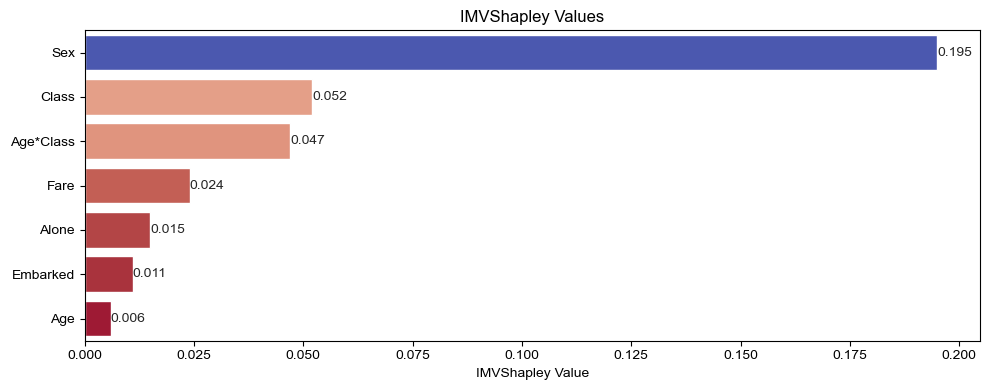

PosixPath('/Users/valler/Python/imv_ml_package/examples/shap_imv/figures/shap_imv_titanic_package_demo.png')

In [4]:
fig,ax=evaluator.evaluate_imvshapley(figsize=(10,4)); fig.tight_layout(); figure_path=FIGURES/"shap_imv_titanic_package_demo.png"; fig.savefig(figure_path,dpi=180,bbox_inches="tight"); plt.show(); figure_path